In [1]:
%load_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import numpy as np
import torch

import wandb
from src.models.light_gcot import LightGCOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.paired import generate_paired_data, get_GT_points, get_paired_sampler
from src.utils.plotting.distributions import plot_swiss_roll

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 50
M_POTENTIALS = 10
EPSILON = 1.0
INIT_BY_SAMPLES = True
A_DIAGONAL_INIT = 0.1

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

D_LR_PAIRED = 3e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_LR_UNPAIRED = 1e-3 
D_GRADIENT_MAX_NORM = float("inf")

M_X_UNPAIRED_SAMPLES = 1024
N_Y_UNPAIRED_SAMPLES = 1024
L_PAIRED_SAMPLES = 64

PLOT_EVERY = 1000
MAX_STEPS = 250000
CONTINUE = -1

EXP_COST = "MLP"
EXP_COST_INCLUDED = True
MINIBATCH_COST = "rotation-v2"

EMA_UPDATE = False

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)

In [7]:
EXP_META_INFO = ""
EXP_NAME = (
    "Light-GCOT_Swiss_Roll_"
    + f"EPSILON_{EPSILON}_"
    + f"MAX_STEPS_{MAX_STEPS}_"
    + f"N_{N_POTENTIALS}_"
    + f"M_{M_POTENTIALS}_"
    + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_"
    + f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_"
    + f"N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_"
    + f"L_PAIRED_{L_PAIRED_SAMPLES}_"
    + f"LR_PAIRED_{D_LR_PAIRED}_"
    + f"LR_UNPAIRED_{D_LR_UNPAIRED}_"
    + f"MINIBATCH_COST_{MINIBATCH_COST}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

## 3. Create data and samplers

In [8]:
X_sampler = StandardNormalSampler(dim=2, device=device)
Y_sampler = SwissRollSampler(dim=2, device=device, dtype=dtype)

In [9]:
otp_sampler = OTPlanSampler("sinkhorn", cost_function=MINIBATCH_COST)

In [10]:
data_dir = "checkpoints/Tensors"
file_postfix = f"{MINIBATCH_COST}_{L_PAIRED_SAMPLES}"

In [11]:
X_paired_train, Y_paired_train, X_paired_test, Y_paired_test = generate_paired_data(
    X_sampler, Y_sampler, otp_sampler, L_PAIRED_SAMPLES, "./checkpoints/Tensors", file_postfix, device=device
)

In [12]:
pd_train_sampler = get_paired_sampler(X_paired_train, Y_paired_train, BATCH_SIZE, L_PAIRED_SAMPLES, device)

In [13]:
X_unpaired_test = X_sampler.sample(L_PAIRED_SAMPLES)
Y_unpaired_test = Y_sampler.sample(L_PAIRED_SAMPLES)

In [14]:
if M_X_UNPAIRED_SAMPLES > 0:
    source_data = X_sampler.sample(M_X_UNPAIRED_SAMPLES)
    usd_sampler = DatasetSampler(source_data, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(X_paired_train, device=device)

if N_Y_UNPAIRED_SAMPLES > 0:
    target_data = Y_sampler.sample(N_Y_UNPAIRED_SAMPLES)
    utd_sampler = DatasetSampler(target_data, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(Y_paired_train, device=device)

## 4. Plotting

In [15]:
# starting_points = torch.tensor([[-2.0, 0.0], [2.0, 2.0], [0.0, -2.0]])
starting_points = torch.tensor([[-2.0, 0.0], [2.0, 2.0], [-0.5, -0.75]])

In [16]:
gt_Y_points = get_GT_points(X_sampler, Y_sampler, otp_sampler, starting_points)

 17%|██████████████████▏                                                                                       | 11/64 [00:00<00:01, 37.75it/s]/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 86.23it/s]


In [17]:
M_X_unpaired_samples_list = [0, 1024]
N_Y_unpaired_samples_list = [0, 1024]
log_step = 99000

In [18]:
models_dict = dict()

for i, M_X_unpaired_samples in enumerate(M_X_unpaired_samples_list):
    for j, N_Y_unpaired_samples in enumerate(N_Y_unpaired_samples_list):
        model = LightGCOT(
            x_dim=X_DIM,
            y_dim=Y_DIM,
            n_potentials=N_POTENTIALS,
            m_potentials=M_POTENTIALS,
            epsilon=EPSILON,
            sampling_batch_size=SAMPLING_BATCH_SIZE,
            A_diagonal_init=A_DIAGONAL_INIT,
            cost_function=EXP_COST,
        )
        exp_name = EXP_NAME.replace(
            f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_",
            f"M_X_UNPAIRED_{M_X_unpaired_samples}_N_Y_UNPAIRED_{N_Y_unpaired_samples}_",
        )
        print(exp_name)
        output_path = "../checkpoints/{}".format(exp_name)
        model.load_state_dict(torch.load(os.path.join(output_path, f"D_{log_step}.pt"), map_location=device))
        title = f"M={M_X_unpaired_samples}, N={N_Y_unpaired_samples}, L={L_PAIRED_SAMPLES}"
        models_dict[title] = model

Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_0_N_Y_UNPAIRED_0_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_MINIBATCH_COST_rotation-v2_
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_0_N_Y_UNPAIRED_1024_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_MINIBATCH_COST_rotation-v2_
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_1024_N_Y_UNPAIRED_0_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_MINIBATCH_COST_rotation-v2_
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_1024_N_Y_UNPAIRED_1024_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_MINIBATCH_COST_rotation-v2_


In [19]:
SAVE_DIR = "./plots/Swiss_Roll/"

Saved ./plots/Swiss_Roll/source_target.png
Saved ./plots/Swiss_Roll/paired_data.png
Saved ./plots/Swiss_Roll/gt_mapping.png
Saved ./plots/Swiss_Roll/Light-IOT_M=0, N=0, L=64.png
Saved ./plots/Swiss_Roll/Light-IOT_M=0, N=1024, L=64.png
Saved ./plots/Swiss_Roll/Light-IOT_M=1024, N=0, L=64.png
Saved ./plots/Swiss_Roll/Light-IOT_M=1024, N=1024, L=64.png


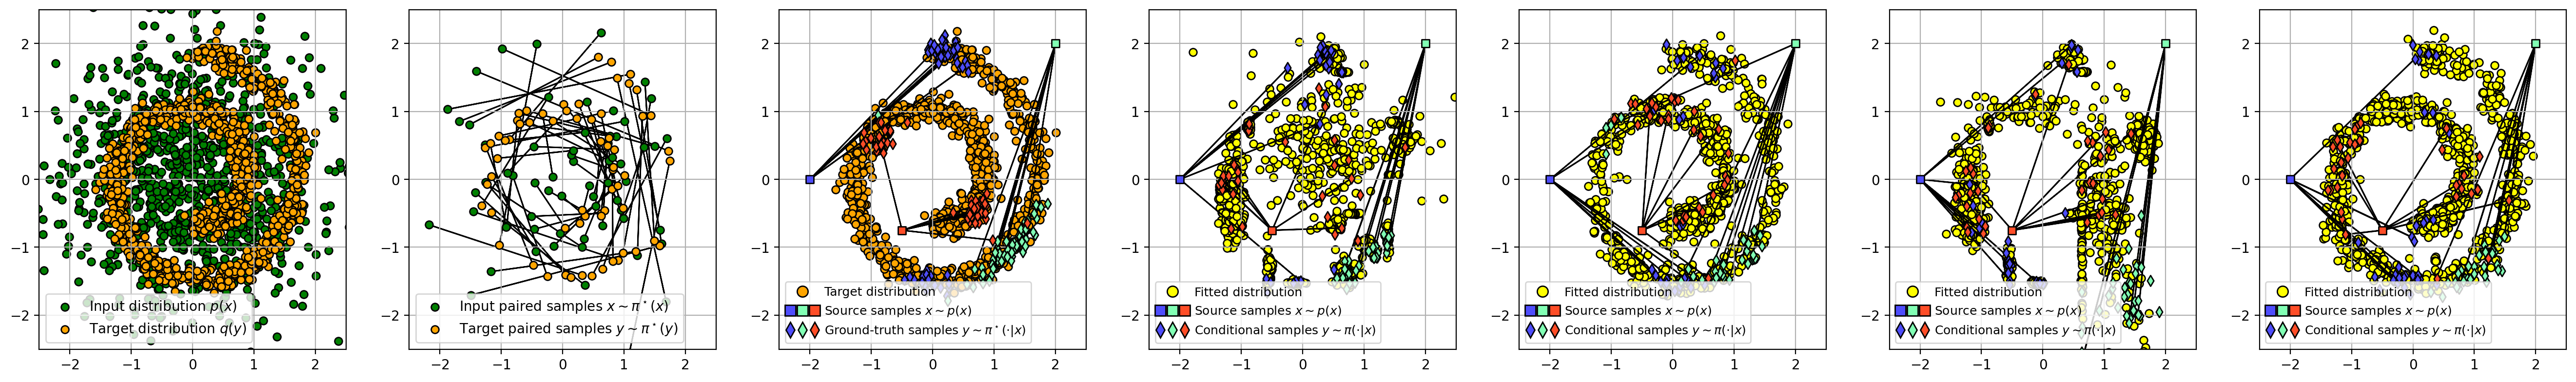

In [26]:
plot_swiss_roll(
    models_dict,
    X_sampler,
    Y_sampler,
    X_paired_train,
    Y_paired_train,
    starting_points,
    gt_Y_points,
    save_dir=SAVE_DIR,
) 